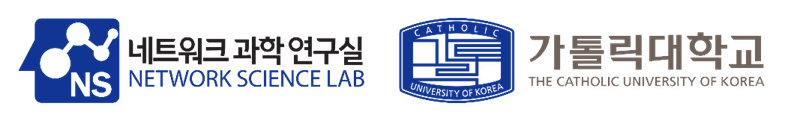

# Week 6: GNNs under Heterophily

A standard GNN computes $\hat Y = f_\theta(\hat A, X)$ with a fixed, low-pass, local operator on the given graph $A$. Under heterophily each of these words can fail, and each remedy of the lecture relaxes one of them:

| Remedy | Models |
|:--|:--|
| 2.1 Beyond low-frequency signal | GPR-GNN, ACM-GCN / ACMII-GCN, FAGCN |
| 2.2 Beyond local neighbourhoods | H2GCN, Geom-GCN |
| 2.3 Advanced architectures | ACMP, GGCN |
| 2.4 Graph structure learning | metric-based GSL, MVGFN, DHGR, ConSM, LGR |
| 2.5 Graph transformers | SignGT |

## Table of contents
- [0. Setup](#0-setup)
- [1. Diagnosis: when does "neighbours look alike" fail?](#1-diagnosis-when-does-neighbours-look-alike-fail)
- [2. Beyond low-frequency signal](#2-beyond-low-frequency-signal)
- [3. Beyond local neighbourhoods](#3-beyond-local-neighbourhoods)
- [4. Advanced architectures](#4-advanced-architectures)
- [5. Graph structure learning](#5-graph-structure-learning)
- [6. Graph transformers: SignGT](#6-graph-transformers-signgt)

# 0. Setup

In [1]:
INSTALL_DEPENDENCIES = False

if INSTALL_DEPENDENCIES:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-geometric"])

In [2]:
import math, time, random, copy, warnings, contextlib, io
warnings.filterwarnings("ignore")                
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid, WebKB, WikipediaNetwork, Actor
from torch_geometric.utils import to_dense_adj

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(0)
HOMO_COLOR, HETERO_COLOR = "#2a78d6", "#eb6834"

Device: cuda


## 0.1. Graph utilities

In [3]:
def sym_norm(A, self_loops=True):
    """Symmetric normalisation  D^{-1/2} (A [+ I]) D^{-1/2}  of a dense (possibly weighted) adjacency."""
    if self_loops:
        A = A + torch.eye(A.size(0), device=A.device)
    d_inv_sqrt = A.sum(1).pow(-0.5)
    d_inv_sqrt[torch.isinf(d_inv_sqrt)] = 0.
    #GCN normalisation: scale messages by both endpoint degrees.
    return d_inv_sqrt[:, None] * A * d_inv_sqrt[None, :]

def row_norm(A):
    """Random-walk normalisation  D^{-1} A  (mean over neighbours)."""
    return A / A.sum(1, keepdim=True).clamp(min=1e-12)

def two_hop(A):
    """Exact 2-hop neighbourhood: reachable in two steps, but not in one step and not the node itself."""
    A2 = ((A @ A) > 0).float()
    #Exact 2-hop neighbours: exclude direct edges, then remove self-loops.
    A2 = A2 * (1 - A)
    A2.fill_diagonal_(0)
    return A2

def input_dropout(x, p, training):
    """Dropout on the (sparse, bag-of-words) input features. Zero entries stay zero under dropout anyway, so we only
    draw random numbers for the non-zero entries: same result as F.dropout, but much faster on large inputs."""
    if not training or p == 0:
        return x
    idx = x.nonzero(as_tuple=True)
    keep = (torch.rand(idx[0].numel(), device=x.device) >= p).float() / (1 - p)
    out = torch.zeros_like(x)
    out[idx] = x[idx] * keep
    return out

def edges_of(A):
    """Directed edge list (both directions) of a dense adjacency: rows i (receivers) and columns j (senders)."""
    return A.nonzero(as_tuple=True)

def as_operator(M, max_density=0.05):
    """Store a fixed propagation matrix as a torch sparse tensor when it is sparse enough (much faster  M @ h  on
    large graphs); keep it dense otherwise. The models only use it as  M @ h, so both formats work."""
    return M.to_sparse() if (M != 0).float().mean().item() < max_density else M

def edge_matmul(rows, cols, values, h):
    """out_i = Σ_j w_ij h_j  for edge weights `values` on the edges (rows, cols): a sparse matrix product
    that is differentiable with respect to the edge weights (used by the attention / signed-edge models)."""
    W = torch.sparse_coo_tensor(torch.stack([rows, cols]), values, (h.size(0), h.size(0)))
    return torch.sparse.mm(W, h)

def edge_softmax(scores, rows, N):
    """Softmax of the edge scores over the edges of each receiving node i (its neighbourhood)."""
    m = torch.full((N,), -float('inf'), device=scores.device).scatter_reduce(0, rows, scores.detach(), 'amax')
    e = (scores - m[rows]).exp()
    return e / torch.zeros(N, device=scores.device).index_add_(0, rows, e)[rows]

def cosine_sim(Z):
    Zn = F.normalize(Z, dim=1)
    return Zn @ Zn.t()

def knn_graph(Z, k):
    """Symmetric k-nearest-neighbour graph under cosine similarity (no self-loops)."""
    S = cosine_sim(Z)
    S.fill_diagonal_(-float('inf'))
    idx = S.topk(k, dim=1).indices
    G = torch.zeros_like(S).scatter_(1, idx, 1.)
    return ((G + G.t()) > 0).float()

## 0.2. Datasets

We use one homophilous and two heterophilous graphs, with the standard 60/20/20 splits of Geom-GCN (Pei et al., 2020)

| Dataset | Nodes | Labels | Category |
|:--|:--|:--|:--|
| **Cora** | papers | topic | homophilous |
| **Texas** (WebKB) | university web pages | student / faculty / course / project / staff | malignant heterophily |
| **Chameleon** (Wikipedia) | Wikipedia articles | monthly-traffic bucket | *benign* heterophily |

In [4]:
ROOT = "./data"

class Graph:
    """Dense tensors of one node-classification dataset and its standard (Geom-GCN) splits."""
    def __init__(self, name):
        with contextlib.redirect_stderr(io.StringIO()):           
            if name in ("Cora", "CiteSeer", "PubMed"):
                ds = Planetoid(ROOT, name, split="geom-gcn")
            elif name in ("Texas", "Wisconsin", "Cornell"):
                ds = WebKB(ROOT, name)
            elif name in ("Chameleon", "Squirrel"):
                ds = WikipediaNetwork(ROOT, name.lower())
            elif name == "Actor":
                ds = Actor(f"{ROOT}/Actor")
        data = ds[0]
        self.name, self.N = name, data.num_nodes
        self.C = int(data.y.max()) + 1
        X = data.x.float()
        self.X = (X / X.sum(1, keepdim=True).clamp(min=1)).to(device)   # row-normalised features
        self.F = X.size(1)
        self.y = data.y.to(device)
        A = to_dense_adj(data.edge_index, max_num_nodes=self.N)[0]
        A = ((A + A.t()) > 0).float()                                    # undirected, binary
        A.fill_diagonal_(0)                                              # no self-loops
        self.A = A.to(device)
        self.A_hat = sym_norm(self.A)                                    # GCN propagation matrix
        self.masks = [m.to(device) for m in (data.train_mask, data.val_mask, data.test_mask)]

    def split(self, i):
        """(train, val, test) boolean masks of split i (60/20/20 for WebKB / Wikipedia, Geom-GCN splits for Cora)."""
        return tuple(m[:, i] for m in self.masks)

    def __repr__(self):
        return (f"{self.name}: {self.N} nodes, {int(self.A.sum().item()) // 2} edges, "
                f"{self.F} features, {self.C} classes")

In [5]:
graphs = [Graph(name) for name in ("Texas", "Chameleon", "Cora")]
texas, chameleon, cora = graphs
for g in graphs:
    tr, va, te = g.split(0)
    print(g, f'| split 0: {int(tr.sum())}/{int(va.sum())}/{int(te.sum())} train/val/test nodes')

Texas: 183 nodes, 279 edges, 1703 features, 5 classes | split 0: 87/59/37 train/val/test nodes
Chameleon: 2277 nodes, 31371 edges, 2325 features, 5 classes | split 0: 1092/729/456 train/val/test nodes
Cora: 2708 nodes, 5278 edges, 1433 features, 7 classes | split 0: 1192/796/497 train/val/test nodes


## 0.3. Training and evaluation

Every model is trained full-batch with Adam (lr 0.01, weight decay 5e-4, 300 epochs, early stopping with patience 100 on the validation accuracy). 

We report the mean ± std test accuracy over the first 3 splits (use all 10 splits for a paper-quality comparison).

In [6]:
def accuracy(pred_y, y):
    return (pred_y == y).float().mean().item()

def train_model(model, g, split, epochs=300, lr=0.01, weight_decay=5e-4, patience=100,
                verbose=False, log_every=50):
    """Full-batch training on split `split` with early stopping on validation accuracy.
    The model is called as model(g.X); models that need a graph store their own operators.
    If the model defines reg_loss(), it is added to the cross-entropy (e.g. graph-structure-learning regularisers).
    Returns (best validation accuracy, test accuracy at that epoch)."""
    tr, va, te = g.split(split)
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val, best_val_loss, best_test, bad, best_state = -1., float('inf'), 0., 0, None
    for epoch in range(1, epochs + 1):
        model.train()
        opt.zero_grad()
        out = model(g.X)
        #Supervision uses training nodes only.
        loss = F.cross_entropy(out[tr], g.y[tr])
        if hasattr(model, 'reg_loss'):
            loss = loss + model.reg_loss()
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            out = model(g.X)
            val_loss = F.cross_entropy(out[va], g.y[va]).item()
            pred = out.argmax(1)
            train_acc, val_acc, test_acc = (accuracy(pred[m], g.y[m]) for m in (tr, va, te))
        #Select the checkpoint using validation performance.
        if val_acc > best_val or (val_acc == best_val and val_loss < best_val_loss):
            best_val, best_val_loss, best_test, bad = val_acc, val_loss, test_acc, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            bad += 1
        if verbose and (epoch == 1 or epoch % log_every == 0):
            print(f'Epoch {epoch:>3} | Train Loss: {loss.item():.3f} | Train Acc: {train_acc*100:6.2f}% | '
                  f'Val Loss: {val_loss:.3f} | Val Acc: {val_acc*100:6.2f}%')
        if bad >= patience:
            break
    model.load_state_dict(best_state)
    if verbose:
        print(f'>> Val Acc: {best_val*100:.2f}% | Test Acc: {best_test*100:.2f}%')
    return best_val, best_test

RESULTS = {}

def benchmark(name, make_model, graphs, splits=(0, 1, 2), **train_kwargs):
    """Train make_model(g, split) on every graph and split; store and print the mean ± std test accuracy."""
    row = []
    for g in graphs:
        accs = []
        for s in splits:
            set_seed(s)
            _, test_acc = train_model(make_model(g, s), g, s, **train_kwargs)
            accs.append(test_acc)
        RESULTS[(name, g.name)] = np.array(accs)
        row.append(f'{g.name}: {np.mean(accs)*100:5.1f} ± {np.std(accs)*100:4.1f}')
    print(f'{name:<10} | ' + ' | '.join(row))

def results_table(models=None, datasets=None):
    models = models or list(dict.fromkeys(m for m, _ in RESULTS))
    datasets = datasets or list(dict.fromkeys(d for _, d in RESULTS))
    return pd.DataFrame({d: [f"{RESULTS[(m, d)].mean()*100:.1f} ± {RESULTS[(m, d)].std()*100:.1f}"
                             if (m, d) in RESULTS else "" for m in models] for d in datasets}, index=models)

SPLITS = (0, 1, 2)
HIDDEN = 64

# 1. Diagnosis: when does "neighbours look alike" fail?
## 1.1. Homophily metrics

The sample code of this week studies the homophily metrics in detail; here we only recompute the main ones, and add label informativeness:

$$LI = \frac{I(y_u; y_v)}{H(y_u)} \quad\text{over the edges } (u,v)$$

$LI$ does not care about the sign of the relation: if class A always links to class B, $h_{edge}=0$ but $LI = 1$ (the neighbour's label tells everything).

In [7]:
def edge_homophily(A, y):
    """Fraction of edges that join two nodes of the same class."""
    src, dst = edges_of(A)
    return (y[src] == y[dst]).float().mean().item()

def node_homophily(A, y):
    """Per-node fraction of same-class neighbours, averaged over nodes with at least one neighbour."""
    same = (y[:, None] == y[None, :]).float()
    deg = A.sum(1)
    h = (A * same).sum(1)[deg > 0] / deg[deg > 0]
    return h.mean().item()

def local_homophily(A, y):
    """Vector of per-node homophily values (NaN for isolated nodes)."""
    same = (y[:, None] == y[None, :]).float()
    deg = A.sum(1)
    return ((A * same).sum(1) / deg).cpu().numpy()

def class_homophily(A, y):
    """Class-insensitive homophily (Lim et al., 2021): per-class homophily minus the class prior."""
    C = int(y.max()) + 1
    src, dst = edges_of(A)
    total = 0.
    for k in range(C):
        from_k = y[src] == k
        if from_k.any():
            h_k = (y[dst][from_k] == k).float().mean().item()
            total += max(0., h_k - (y == k).float().mean().item())
    return total / (C - 1)

def adjusted_homophily(A, y):
    """Edge homophily corrected for chance (Platonov et al., 2023); 0 = random wiring, < 0 = heterophily."""
    C = int(y.max()) + 1
    deg = A.sum(1)
    p = torch.zeros(C, device=A.device).index_add_(0, y, deg) / deg.sum()
    chance = (p ** 2).sum().item()
    #Adjusted homophily removes same-class agreement expected by chance.
    return (edge_homophily(A, y) - chance) / (1 - chance)

def compatibility_matrix(A, y):
    """H[k, l] = fraction of edges leaving class k that land in class l."""
    C = int(y.max()) + 1
    Y = F.one_hot(y, C).float()
    H = Y.t() @ A @ Y
    return (H / H.sum(1, keepdim=True).clamp(min=1)).cpu().numpy()

def label_informativeness(A, y):
    """LI = I(y_u; y_v) / H(y_u) over edges (Platonov et al., 2023): how much a neighbour's label tells
    about the node's label, whatever the sign of the relation (1 = fully informative, 0 = useless)."""
    C = int(y.max()) + 1
    Y = F.one_hot(y, C).float()
    P = Y.t() @ A @ Y
    P = P / P.sum()                                 # joint distribution p(c1, c2) of the labels at an edge
    p = P.sum(1)                                    # marginal (degree-weighted class distribution)
    H_joint = -(P[P > 0] * P[P > 0].log()).sum()
    H_marg = -(p[p > 0] * p[p > 0].log()).sum()
    #Label informativeness captures useful relations even across different classes.
    return (2 - H_joint / H_marg).item()            # (2 H(p) - H(P)) / H(p)

In [8]:
metric_fns = {'h_edge': edge_homophily, 'h_node': node_homophily, 'h_class': class_homophily,
              'h_adj': adjusted_homophily, 'LI': label_informativeness}
pd.DataFrame({g.name: {m: f(g.A, g.y) for m, f in metric_fns.items()} for g in graphs}).T.round(3)

,h_edge,h_node,h_class,h_adj,LI
Texas,0.061,0.057,0.000,-0.294,0.192
Chameleon,0.230,0.247,0.041,0.032,0.048
Cora,0.810,0.825,0.766,0.771,0.590


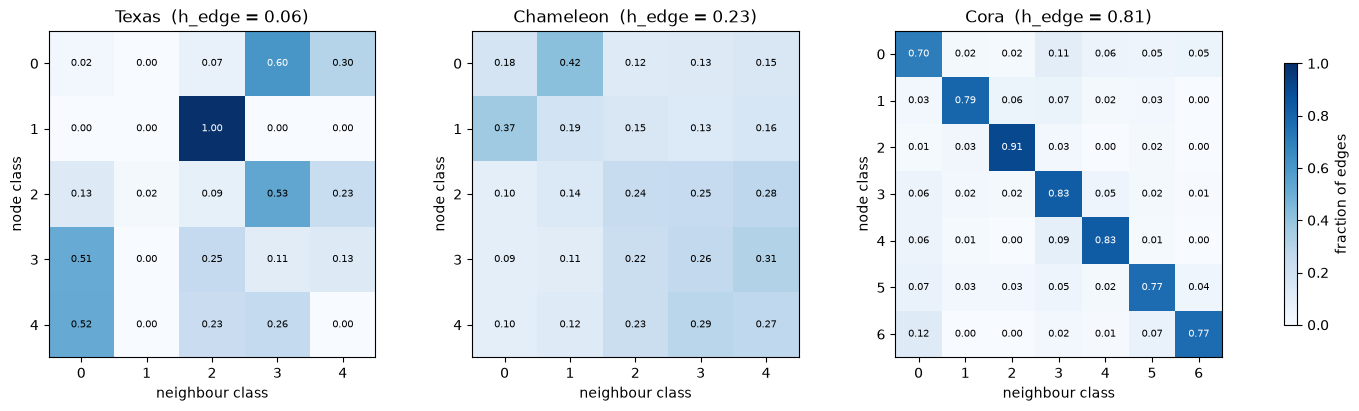

In [9]:
with plt.rc_context({"axes.grid": False}):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
    for ax, g in zip(axes, graphs):
        H = compatibility_matrix(g.A, g.y)
        im = ax.imshow(H, cmap="Blues", vmin=0, vmax=1)
        for (k, l), v in np.ndenumerate(H):
            ax.text(l, k, f"{v:.2f}", ha="center", va="center", fontsize=7, color="white" if v > 0.55 else "black")
        ax.set(title=f"{g.name}  (h_edge = {edge_homophily(g.A, g.y):.2f})", xlabel="neighbour class",
               ylabel="node class", xticks=range(g.C), yticks=range(g.C))
    fig.colorbar(im, ax=axes, shrink=0.8, label="fraction of edges")
    plt.show()

## 1.2. Heterophilous labels live at high frequencies

Write the one-hot label matrix $Y$ in the eigenbasis of the normalised Laplacian $L = I - D^{-1/2} A D^{-1/2} = U \Lambda U^\top$. The fraction of the label energy carried by eigenvalue $\lambda_k$ is $\|(U^\top Y)_k\|^2 / \|Y\|_F^2$. A GCN keeps the components with small $\lambda$ (filter $(1-\lambda)^K$) and damps the others: it can only help if the labels are smooth (energy at low $\lambda$).

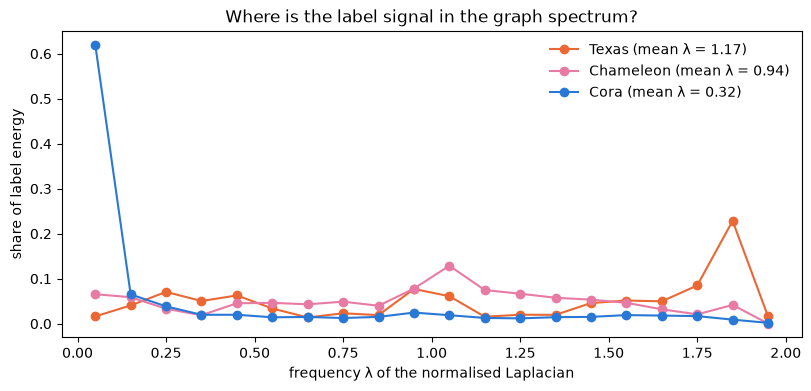

In [10]:
def label_spectrum(g):
    L = torch.eye(g.N, device=device) - sym_norm(g.A, self_loops=False)
    lam, U = torch.linalg.eigh(L.double())
    Y = F.one_hot(g.y, g.C).double()
    Y = Y - Y.mean(0)                                   # remove the constant component
    #Project labels onto graph eigenvectors to measure energy at each frequency.
    energy = (U.t() @ Y).pow(2).sum(1)
    return lam.cpu().numpy(), (energy / energy.sum()).cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 3.8), constrained_layout=True)
bins = np.linspace(0, 2, 21)
for g, c in zip(graphs, [HETERO_COLOR, "#e87ba4", HOMO_COLOR]):
    lam, e = label_spectrum(g)
    hist, _ = np.histogram(lam, bins=bins, weights=e)
    ax.plot((bins[:-1] + bins[1:]) / 2, hist, 'o-', color=c, label=f"{g.name} (mean λ = {(lam * e).sum():.2f})")
ax.set(xlabel="frequency λ of the normalised Laplacian", ylabel="share of label energy",
       title="Where is the label signal in the graph spectrum?")
ax.legend(frameon=False)
plt.show()

Cora's labels are concentrated at **low** frequencies (λ < 0.5): a low-pass filter keeps them. Texas puts a large share of the label energy at **high** frequencies (λ > 1): a low-pass filter removes exactly what we need. This is the motivation of Section 2.

## 1.3. Good vs. bad heterophily

Heterophily is not always harmful. Two synthetic graphs with edge homophily 0:

* good (bipartite, 2 classes): every class-0 node links only to class-1 nodes and vice versa. After mean aggregation, all class-0 nodes receive the same (class-1) mean, so the classes stay separable: they are corrupted in the exact same way.
* bad (4 classes): every node links to nodes of random other classes, so all classes receive almost the same mixture.

We compare a logistic regression on the raw features $X$ and on the aggregated features $D^{-1}AX$.

In [11]:
from sklearn.linear_model import LogisticRegression

def synthetic_heterophily(kind, n=800, deg=6, dim=16, noise=2.5, seed=0):
    rng = np.random.default_rng(seed)
    C = 2 if kind == 'good' else 4
    y = rng.integers(0, C, n)
    means = rng.normal(0, 1, (C, dim))
    X = means[y] + noise * rng.normal(0, 1, (n, dim))           # weak, noisy features
    A = np.zeros((n, n))
    for v in range(n):
        if kind == 'good':
            others = np.flatnonzero(y == 1 - y[v])                 # the other class
        else:
            other_classes = rng.choice([c for c in range(C) if c != y[v]], size=deg)
            others = np.array([rng.choice(np.flatnonzero(y == c)) for c in other_classes])
        nb = rng.choice(others, size=deg // 2, replace=False) if kind == 'good' else others[:deg // 2]
        A[v, nb] = A[nb, v] = 1
    return (torch.tensor(A, dtype=torch.float, device=device), torch.tensor(X, dtype=torch.float, device=device),
            torch.tensor(y, device=device))

def linear_probe(Z, y, seed=0):
    idx = np.random.default_rng(seed).permutation(len(y))
    tr, te = idx[:len(y) // 2], idx[len(y) // 2:]
    clf = LogisticRegression(max_iter=2000).fit(Z[tr], y[tr])
    return clf.score(Z[te], y[te])

rows = {}
for kind in ('good', 'bad'):
    A_s, X_s, y_s = synthetic_heterophily(kind)
    agg = (row_norm(A_s) @ X_s).cpu().numpy()
    rows[kind] = {'h_edge': edge_homophily(A_s, y_s), 'LI': label_informativeness(A_s, y_s),
                  'acc on X': linear_probe(X_s.cpu().numpy(), y_s.cpu().numpy()),
                  'acc on D⁻¹AX': linear_probe(agg, y_s.cpu().numpy()),
                  'acc on [X ‖ D⁻¹AX]': linear_probe(np.hstack([X_s.cpu().numpy(), agg]), y_s.cpu().numpy())}
pd.DataFrame(rows).T.round(3)

,h_edge,LI,acc on X,acc on D⁻¹AX,acc on [X ‖ D⁻¹AX]
good,0.0,1.000,0.855,0.982,0.992
bad,0.0,0.208,0.692,0.535,0.735


Both graphs have $h_{edge} = 0$, but aggregation helps a lot on the bipartite graph and does not help on the random-heterophily graph. Edge homophily cannot tell them apart; label informativeness can ($LI = 1$ vs. $LI \approx 0.2$: in the second graph a neighbour's label only says which class the node is not). What matters is whether same-class nodes have similar neighbourhood distributions*.

## 1.4. Classifier-based Performance Metric (CPM)

CPM asks directly whether aggregation helps a *non-iterative* classifier: sample 500 nodes, split 60/40, train a Gaussian Naive Bayes on $X$ and on $H = \hat A X$, repeat 100 times and test

$$H_0: \text{Acc}(H) \ge \text{Acc}(X) \qquad\text{vs.}\qquad H_1: \text{Acc}(H) < \text{Acc}(X).$$

A **small p-value** means aggregation is significantly *harmful* (malignant heterophily).

In [12]:
from sklearn.naive_bayes import GaussianNB
from scipy import stats

def cpm(g, n_samples=500, reps=100, seed=0):
    rng = np.random.default_rng(seed)
    #Compare predictability before and after neighbour aggregation.
    X, H, y = g.X.cpu().numpy(), (g.A_hat @ g.X).cpu().numpy(), g.y.cpu().numpy()
    acc_X, acc_H = [], []
    for _ in range(reps):
        idx = rng.choice(g.N, size=min(n_samples, g.N), replace=False)
        cut = int(0.6 * len(idx))
        tr, te = idx[:cut], idx[cut:]
        acc_X.append(GaussianNB().fit(X[tr], y[tr]).score(X[te], y[te]))
        acc_H.append(GaussianNB().fit(H[tr], y[tr]).score(H[te], y[te]))
    p_value = stats.ttest_ind(acc_H, acc_X, alternative='less').pvalue
    return np.mean(acc_X), np.mean(acc_H), p_value

pd.DataFrame({g.name: dict(zip(['GNB acc on X', 'GNB acc on ÂX', 'p-value (H1: aggregation hurts)'], cpm(g)))
              for g in graphs}).T.round(4)

,GNB acc on X,GNB acc on ÂX,p-value (H1: aggregation hurts)
Texas,0.6699,0.2080,0.0
Chameleon,0.4043,0.4580,1.0
Cora,0.4726,0.6092,1.0


## 1.5. Baselines: MLP vs. GCN

In [13]:
class MLP(nn.Module):
    """2-layer MLP"""
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.lin1, self.lin2, self.dropout = nn.Linear(in_dim, hidden_dim), nn.Linear(hidden_dim, out_dim), dropout

    def forward(self, x):
        x = input_dropout(x, self.dropout, self.training)
        self.hidden = F.relu(self.lin1(x))
        return self.lin2(F.dropout(self.hidden, self.dropout, self.training))


class GCN(nn.Module):
    """2-layer GCN  Â ReLU(Â X W1) W2  on a given (normalised) propagation matrix."""
    def __init__(self, in_dim, hidden_dim, out_dim, A_hat, dropout=0.5):
        super().__init__()
        self.lin1, self.lin2 = nn.Linear(in_dim, hidden_dim), nn.Linear(hidden_dim, out_dim)
        self.A_hat, self.dropout = as_operator(A_hat), dropout

    def forward(self, x):
        x = input_dropout(x, self.dropout, self.training)
        #GCN mixes neighbour features through the normalised adjacency.
        x = F.relu(self.A_hat @ self.lin1(x))
        x = F.dropout(x, self.dropout, self.training)
        return self.A_hat @ self.lin2(x)

In [14]:
benchmark('MLP', lambda g, s: MLP(g.F, HIDDEN, g.C), graphs, SPLITS)
benchmark('GCN', lambda g, s: GCN(g.F, HIDDEN, g.C, g.A_hat), graphs, SPLITS)

MLP        | Texas:  78.4 ±  3.8 | Chameleon:  46.4 ±  1.3 | Cora:  75.5 ±  3.2
GCN        | Texas:  59.5 ±  4.4 | Chameleon:  55.8 ±  3.1 | Cora:  87.8 ±  1.6


The MLP, which ignores the graph, beats the GCN by a wide margin on Texas, while the GCN wins on Cora. On Chameleon, a benign heterophilous graph, the GCN is still better than the MLP.

# 2. Beyond low-frequency signal
Heterophilous labels live at high frequencies: let the model keep them with learnable / high-pass / signed filters.
## 2.1. GPR-GNN: learn the propagation filter

$$H^{(0)} = f_\theta(X),\qquad Z = \sum_{k=0}^{K}\gamma_k \hat A^k H^{(0)},\qquad h(\lambda) = \sum_{k=0}^K \gamma_k (1-\lambda)^k$$

The $\gamma_k$ are learned and may be negative, so the filter can become high-pass.

In [15]:
class GPRGNN(nn.Module):
    """GPR-GNN:  Z = Σ_k γ_k Â^k f_θ(X)  with learnable (possibly negative) γ_k."""
    def __init__(self, in_dim, hidden_dim, out_dim, A_hat, K=10, alpha=0.1, dropout=0.5, dprate=0.5, init='ppr'):
        super().__init__()
        self.mlp = MLP(in_dim, hidden_dim, out_dim, dropout)
        if init == 'ppr':                                                       # PPR initialisation (low-pass)
            gamma = alpha * (1 - alpha) ** torch.arange(K + 1, dtype=torch.float)
            gamma[-1] = (1 - alpha) ** K
        else:                                                                   # random initialisation
            bound = math.sqrt(3 / (K + 1))
            gamma = torch.empty(K + 1).uniform_(-bound, bound)
            gamma = gamma / gamma.abs().sum()
        #Learn the hop weights; they can become negative.
        self.gamma = nn.Parameter(gamma)
        self.A_hat, self.K, self.dprate = as_operator(A_hat), K, dprate

    def forward(self, x):
        h = F.dropout(self.mlp(x), self.dprate, self.training)
        z = self.gamma[0] * h
        for k in range(1, self.K + 1):
            h = self.A_hat @ h
            #Combine different propagation depths into a learnable graph filter.
            z = z + self.gamma[k] * h
        return z

def gpr_response(gamma, lam):
    """Frequency response h(λ) = Σ_k γ_k (1 - λ)^k of a GPR filter on the normalised Laplacian."""
    return sum(g_k * (1 - lam) ** k for k, g_k in enumerate(gamma))

In [16]:
benchmark('GPR-GNN', lambda g, s: GPRGNN(g.F, HIDDEN, g.C, g.A_hat), graphs, SPLITS)

GPR-GNN    | Texas:  67.6 ±  5.8 | Chameleon:  57.5 ±  2.4 | Cora:  88.5 ±  1.3


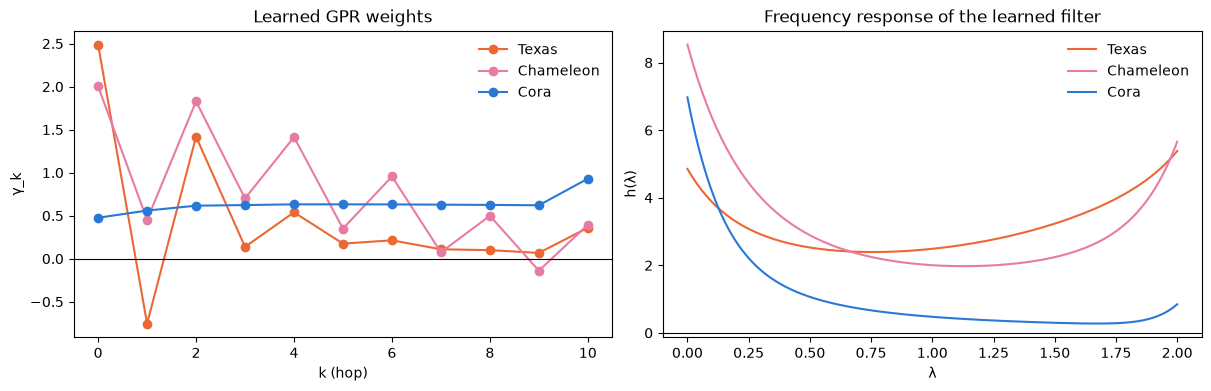

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
lam = np.linspace(0, 2, 200)
for g, c in zip(graphs, [HETERO_COLOR, "#e87ba4", HOMO_COLOR]):
    set_seed(0)
    model = GPRGNN(g.F, HIDDEN, g.C, g.A_hat)
    train_model(model, g, 0)
    gamma = model.gamma.detach().cpu().numpy()
    axes[0].plot(gamma, 'o-', color=c, label=g.name)
    axes[1].plot(lam, gpr_response(gamma, lam), color=c, label=g.name)
axes[0].set(xlabel='k (hop)', ylabel='γ_k', title='Learned GPR weights')
axes[1].set(xlabel='λ', ylabel='h(λ)', title='Frequency response of the learned filter')
for ax in axes:
    ax.axhline(0, color='black', lw=0.8)
    ax.legend(frameon=False)
plt.show()

On Cora all $\gamma_k$ are positive and the filter stays low-pass ($h(\lambda)$ large near $\lambda=0$, small elsewhere). 

On Texas and Chameleon the model learns a large $\gamma_0$ (the node's own features) and weights of alternating sign (on Texas $\gamma_1 < 0$): $(1-\lambda)^k$ with odd $k$ is negative for $\lambda > 1$, so the response rises again at high frequencies. 

The learned filters keep both ends of the spectrum, exactly where the label energy of these graphs.

## 2.2. Adaptive Channel Mixing: ACM-GCN

GPR-GNN learns one filter for the whole graph. ACM filters every layer with three channels and mixes them per node:

| Channel | ACM (filter → ReLU) | ACMII (ReLU → filter) |
|:--|:--|:--|
| low-pass (aggregation) | $H_L = \text{ReLU}(H_{LP} H W_L)$ | $H_L = H_{LP}\,\text{ReLU}(H W_L)$ |
| high-pass (diversification) | $H_H = \text{ReLU}(H_{HP} H W_H)$ | $H_H = H_{HP}\,\text{ReLU}(H W_H)$ |
| identity | $H_I = \text{ReLU}(H W_I)$ | $H_I = \text{ReLU}(H W_I)$ |

with $H_{LP} = \hat A$ and $H_{HP} = I - \hat A$. Node-wise weights: $\tilde\alpha_c = \sigma(H_c \tilde W_c)$, $[\alpha_L, \alpha_H, \alpha_I] = \text{softmax}([\tilde\alpha_L, \tilde\alpha_H, \tilde\alpha_I] / T \cdot W_{mix})$, and

$$H^{(l)} = \text{ReLU}\big(\text{diag}(\alpha_L) H_L + \text{diag}(\alpha_H) H_H + \text{diag}(\alpha_I) H_I\big).$$

In [18]:
class ACMLayer(nn.Module):
    """Adaptive Channel Mixing layer (Luan et al., NeurIPS 2022).
    Channels: low-pass Â, high-pass I - Â, identity I.
    variant='ACM'  : H_c = ReLU(F_c H W_c)   (filter before the non-linearity)
    variant='ACMII': H_c = F_c ReLU(H W_c)   (non-linearity before the filter)
    Node-wise mixing weights: α = softmax([σ(H_L w_L), σ(H_H w_H), σ(H_I w_I)] / T · W_mix)."""
    def __init__(self, in_dim, out_dim, A_hat, variant='ACM', channels=('L', 'H', 'I'), T=3.0, last=False):
        super().__init__()
        self.channels, self.variant, self.T, self.last = channels, variant, T, last
        self.W = nn.ModuleDict({c: nn.Linear(in_dim, out_dim) for c in channels})
        self.att = nn.ModuleDict({c: nn.Linear(out_dim, 1) for c in channels})
        self.W_mix = nn.Parameter(torch.eye(len(channels)))
        I = torch.eye(A_hat.size(0), device=A_hat.device)
        #Three channels: low-pass, high-pass, and unchanged ego features.
        self.filters = {'L': as_operator(A_hat), 'H': as_operator(I - A_hat), 'I': None}

    def _filter(self, c, h):
        return h if self.filters[c] is None else self.filters[c] @ h

    def forward(self, h):
        H = []
        for c in self.channels:
            if self.variant == 'ACM':
                z = self._filter(c, self.W[c](h))
                H.append(z if self.last else F.relu(z))
            else:
                H.append(self._filter(c, F.relu(self.W[c](h))))
        scores = torch.cat([torch.sigmoid(self.att[c](z)) for c, z in zip(self.channels, H)], dim=1)
        alpha = torch.softmax(scores / self.T @ self.W_mix, dim=1)      # (N, #channels) node-wise weights
        self.alpha = alpha.detach()
        #Each node learns its own mixture of the three channels.
        out = sum(alpha[:, i:i + 1] * z for i, z in enumerate(H))
        return out if self.last else F.relu(out)


class ACMGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, A_hat, variant='ACM', channels=('L', 'H', 'I'), dropout=0.5):
        super().__init__()
        self.layer1 = ACMLayer(in_dim, hidden_dim, A_hat, variant, channels)
        self.layer2 = ACMLayer(hidden_dim, out_dim, A_hat, variant, channels, last=True)
        self.dropout = dropout

    def forward(self, x):
        x = input_dropout(x, self.dropout, self.training)
        x = F.dropout(self.layer1(x), self.dropout, self.training)
        return self.layer2(x)

In [19]:
benchmark('ACM-GCN', lambda g, s: ACMGCN(g.F, HIDDEN, g.C, g.A_hat, variant='ACM'), graphs, SPLITS)
benchmark('ACMII-GCN', lambda g, s: ACMGCN(g.F, HIDDEN, g.C, g.A_hat, variant='ACMII'), graphs, SPLITS)

ACM-GCN    | Texas:  78.4 ±  5.8 | Chameleon:  47.9 ±  0.5 | Cora:  87.3 ±  0.9
ACMII-GCN  | Texas:  72.1 ± 16.6 | Chameleon:  50.9 ±  2.0 | Cora:  79.4 ±  5.9


Which channels does the model use? Mean mixing weights $\alpha_L, \alpha_H, \alpha_I$ of each layer (averaged over the nodes), after training on split 0.

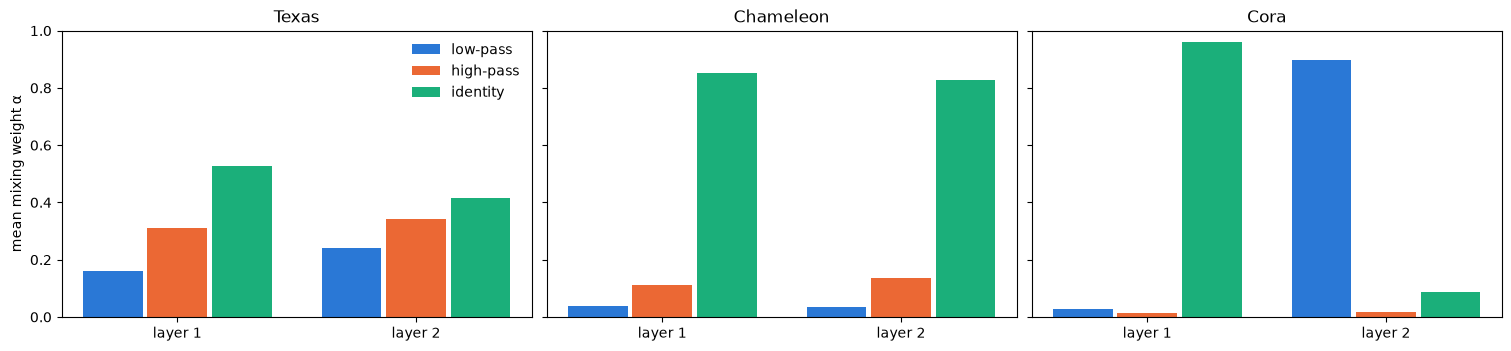

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4), sharey=True, constrained_layout=True)
for ax, g in zip(axes, graphs):
    set_seed(0)
    model = ACMGCN(g.F, HIDDEN, g.C, g.A_hat)
    train_model(model, g, 0)
    model.eval()
    with torch.no_grad():
        model(g.X)
    for l, layer in enumerate([model.layer1, model.layer2]):
        mean_alpha = layer.alpha.mean(0).cpu().numpy()
        for i, (ch, c) in enumerate(zip(['low-pass', 'high-pass', 'identity'], [HOMO_COLOR, HETERO_COLOR, '#1baf7a'])):
            ax.bar(l + (i - 1) * 0.27, mean_alpha[i], 0.25, color=c, label=ch if l == 0 else None)
    ax.set(title=g.name, xticks=[0, 1], xticklabels=['layer 1', 'layer 2'], ylim=(0, 1))
    ax.grid(axis='x', visible=False)
axes[0].set_ylabel('mean mixing weight α')
axes[0].legend(frameon=False)
plt.show()

* **Texas**: both layers use a mixture dominated by the identity channel, with a large high-pass share and little low-pass: the model mostly keeps the ego features and the differences to the neighbours.
* **Cora**: layer 1 is almost purely identity (an MLP-like feature extractor) and layer 2 almost purely low-pass: ACM rediscovers the "transform, then propagate" design of APPNP / GPR-GNN.
* **Chameleon**: the identity channel dominates both layers. The mixing weights are trained on the training loss, and the identity (MLP) channel fits the training nodes most easily, so ACM-GCN ends up close to the MLP here, below GCN. Node-wise mixing adds flexibility, and with it a risk of over-fitting.

## 2.3. FAGCN: frequency adaptation with signed edge weights

$\mathcal F_L = \varepsilon I + D^{-1/2}AD^{-1/2}$ (low-pass) and $\mathcal F_H = \varepsilon I - D^{-1/2}AD^{-1/2}$ (high-pass). 

FAGCN lets every edge choose between them with a coefficient $\alpha_{ij} = \tanh(g^\top[h_i \| h_j]) \in (-1, 1)$:

$$h_i' = \varepsilon\, h_i^{(0)} + \sum_{j \in \mathcal N(i)} \frac{\alpha_{ij}}{\sqrt{d_i d_j}}\, h_j \qquad (\alpha_{ij} > 0:\ \text{sum / low-pass},\quad \alpha_{ij} < 0:\ \text{difference / high-pass})$$

In [21]:
class FAGCN(nn.Module):
    """FAGCN (Bo et al., AAAI 2021): signed edge coefficients α_ij = tanh(gᵀ[h_i ‖ h_j]) ∈ (-1, 1)
    α_ij > 0 -> low-pass (sum, ε I + Â)   |   α_ij < 0 -> high-pass (difference, ε I - Â)
    h_i ← ε h_i^(0) + Σ_j α_ij / sqrt(d_i d_j) h_j      (computed on the edge list)"""
    def __init__(self, in_dim, hidden_dim, out_dim, A, eps=0.3, num_layers=2, dropout=0.5):
        super().__init__()
        self.lin_in, self.lin_out = nn.Linear(in_dim, hidden_dim), nn.Linear(hidden_dim, out_dim)
        self.gate_i = nn.ModuleList([nn.Linear(hidden_dim, 1) for _ in range(num_layers)])
        self.gate_j = nn.ModuleList([nn.Linear(hidden_dim, 1, bias=False) for _ in range(num_layers)])
        self.rows, self.cols = edges_of(A)                      # edge (i, j): j sends a message to i
        d_inv_sqrt = A.sum(1).clamp(min=1).pow(-0.5)
        self.norm = d_inv_sqrt[self.rows] * d_inv_sqrt[self.cols]   # 1 / sqrt(d_i d_j) on every edge
        self.eps, self.dropout = eps, dropout

    def forward(self, x):
        x = input_dropout(x, self.dropout, self.training)
        h = F.dropout(F.relu(self.lin_in(x)), self.dropout, self.training)
        h0 = h
        for g_i, g_j in zip(self.gate_i, self.gate_j):
            #Signed edge weights let neighbour messages add or subtract information.
            alpha = torch.tanh(g_i(h)[self.rows, 0] + g_j(h)[self.cols, 0])   # one signed coefficient per edge
            self.alpha = alpha.detach()                                      # aligned with edges_of(A)
            #Retain the initial node representation while aggregating signed messages.
            h = self.eps * h0 + edge_matmul(self.rows, self.cols, alpha * self.norm, h)
        return self.lin_out(h)

In [22]:
benchmark('FAGCN', lambda g, s: FAGCN(g.F, HIDDEN, g.C, g.A, eps=0.3), graphs, SPLITS)

FAGCN      | Texas:  66.7 ±  7.1 | Chameleon:  61.0 ±  2.5 | Cora:  88.9 ±  1.7


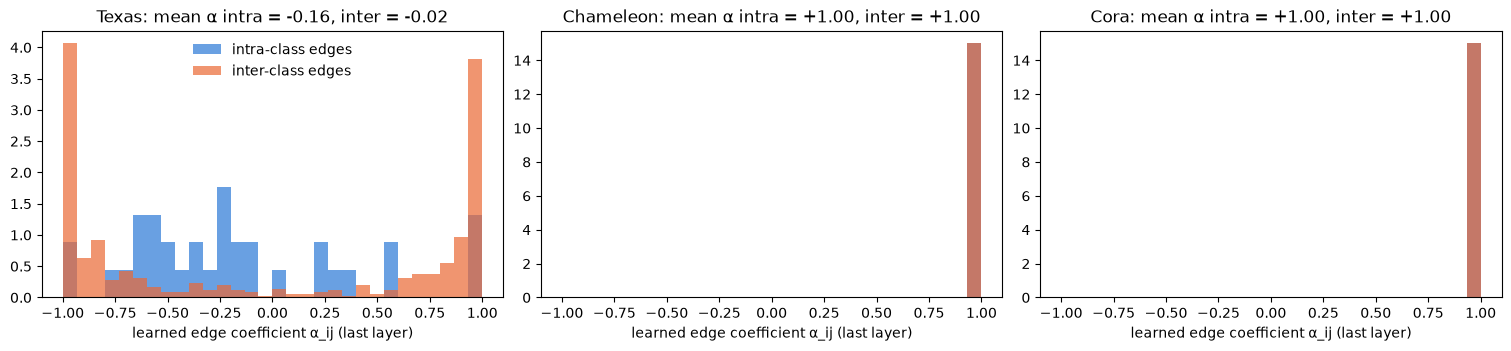

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4), constrained_layout=True)
for ax, g in zip(axes, graphs):
    set_seed(0)
    model = FAGCN(g.F, HIDDEN, g.C, g.A)
    train_model(model, g, 0)
    model.eval()
    with torch.no_grad():
        model(g.X)
    src, dst = edges_of(g.A)
    a = model.alpha.cpu().numpy()                            # one coefficient per edge of edges_of(g.A)
    same = (g.y[src] == g.y[dst]).cpu().numpy()
    ax.hist(a[same], bins=30, range=(-1, 1), alpha=0.7, density=True, color=HOMO_COLOR, label='intra-class edges')
    ax.hist(a[~same], bins=30, range=(-1, 1), alpha=0.7, density=True, color=HETERO_COLOR, label='inter-class edges')
    ax.set(title=f'{g.name}: mean α intra = {a[same].mean():+.2f}, inter = {a[~same].mean():+.2f}',
           xlabel='learned edge coefficient α_ij (last layer)')
axes[0].legend(frameon=False)
plt.show()

The tanh gates saturate: on Chameleon and Cora every coefficient is $+1$ (pure low-pass sum, a GCN without self-loops plus the $\varepsilon$ residual), while on Texas they split into $+1$ and $-1$. 

The negative (high-pass) coefficients are not reserved for inter-class edges: the gate only sees the two endpoint representations, which is the weakness of FAGCN. 

What FAGCN gains on Texas over GCN comes mostly from the $\varepsilon h^{(0)}$ ego term and from being able to subtract neighbours at all.

# 3. Beyond local neighbourhoods
Under heterophily, same-class nodes are often not adjacent. Reach them through higher-order hops or a latent space.
## 3.1. H2GCN

* **D1** ego/neighbour separation: no self-loops, the ego embedding $H^{(0)} = \text{ReLU}(XW_0)$ is kept apart.
* **D2** higher-order neighbourhoods: aggregate the 1-hop ($S_1$) and the exact 2-hop ($S_2$) neighbours separately, $R^{(k)} = [S_1 H^{(k-1)} \,\|\, S_2 H^{(k-1)}]$.
* **D3** combination of intermediate representations: $H_{final} = [H^{(0)} \| R^{(1)} \| \dots \| R^{(K)}]$.

Why 2-hop? In a bipartite graph ($h=0$) every 2-hop neighbour has the same class. MVGFN's Theorem 1 gives, for $C$ classes and neighbours independent of each other, $h_{\mathcal N_2} \approx h^2 + \frac{(1-h)^2}{C-1}$, which is larger than $h$ when $h < 1/C$.

In [24]:
hop_table = {}
for g in graphs:
    h1, C = edge_homophily(g.A, g.y), g.C
    hop_table[g.name] = {'h(1-hop)': h1, 'h(exact 2-hop)': edge_homophily(two_hop(g.A), g.y),
                         'Theorem 1 prediction': h1 ** 2 + (1 - h1) ** 2 / (C - 1), '1 / C': 1 / C}
pd.DataFrame(hop_table).T.round(3)

,h(1-hop),h(exact 2-hop),Theorem 1 prediction,1 / C
Texas,0.061,0.571,0.224,0.200
Chameleon,0.230,0.228,0.201,0.200
Cora,0.810,0.724,0.662,0.143


On Texas the exact 2-hop graph is much more homophilous than the 1-hop graph (0.57 vs. 0.06), far above the Theorem 1 value: the theorem assumes that the labels of neighbours are independent, while real WebKB pages share hubs (two student pages pointing to the same faculty page are both students).

On Chameleon the 2-hop graph is not better, and on Cora it is worse: higher-order neighbourhoods help exactly when $h$ is below the random level $1/C$.

In [25]:
class H2GCN(nn.Module):
    """H2GCN (Zhu et al., NeurIPS 2020).
    D1 ego/neighbour separation : no self-loops in S1, S2 (the ego embedding is kept in H^(0))
    D2 higher-order neighbours  : separate 1-hop S1 and exact 2-hop S2 aggregation
    D3 combination              : concatenate the representations of all rounds  [H0, R1, R2, ...]"""
    def __init__(self, in_dim, hidden_dim, out_dim, A, K=2, dropout=0.5, ego_sep=True, higher=True, combine=True):
        super().__init__()
        A1 = A if ego_sep else A + torch.eye(A.size(0), device=A.device)
        self.S = [as_operator(sym_norm(A1, self_loops=False))]
        if higher:
            A2 = two_hop(A) if ego_sep else two_hop(A) + torch.eye(A.size(0), device=A.device)
            self.S.append(as_operator(sym_norm(A2, self_loops=False)))
        self.embed = nn.Linear(in_dim, hidden_dim)
        m = len(self.S)
        dims = [hidden_dim * m ** k for k in range(K + 1)]
        self.cls = nn.Linear(sum(dims) if combine else dims[-1], out_dim)
        self.K, self.combine, self.dropout = K, combine, dropout

    def forward(self, x):
        x = input_dropout(x, self.dropout, self.training)
        h = F.relu(self.embed(x))                         # H^(0) = ReLU(X W0)
        reps = [h]
        for _ in range(self.K):
            #Keep 1-hop and 2-hop messages in separate feature channels.
            h = torch.cat([S @ h for S in self.S], dim=1)  # R^(k) = [S1 H^(k-1) ‖ S2 H^(k-1)]
            reps.append(h)
        #Preserve ego features and every propagation depth for classification.
        h = torch.cat(reps, dim=1) if self.combine else reps[-1]
        return self.cls(F.dropout(h, self.dropout, self.training))

In [26]:
benchmark('H2GCN', lambda g, s: H2GCN(g.F, HIDDEN, g.C, g.A), graphs, SPLITS)

H2GCN      | Texas:  81.1 ±  5.8 | Chameleon:  55.9 ±  2.0 | Cora:  88.9 ±  1.7


## 3.2. Geom-GCN

1. **Node embedding**: map the nodes into a 2-D latent space. Use Isomap on the graph (classical MDS of the shortest-path distances), one of the three embeddings of the paper.
2. **Structural neighbourhood**: $N(v) = (\{N_g(v), N_s(v)\}, \tau)$, with $N_g$ the graph neighbours and $N_s$ the nodes closer than $\rho$ in the latent space.
3. **Bi-level aggregation** with the relation operator $\tau$ (upper-left, upper-right, lower-left, lower-right): 8 virtual nodes $e_v^{(i,r)}$, concatenated and transformed.

In [27]:
from scipy.sparse.csgraph import shortest_path

def isomap_embedding(A, dim=2):
    """Isomap on the graph: classical MDS of the shortest-path (geodesic) distances -> (N, dim) latent coordinates."""
    D = shortest_path(A.cpu().numpy(), unweighted=True, directed=False)
    D[np.isinf(D)] = D[~np.isinf(D)].max() + 1                # disconnected pairs: just beyond the diameter
    n = len(D)
    J = np.eye(n) - 1. / n
    B = -0.5 * J @ (D ** 2) @ J
    vals, vecs = np.linalg.eigh(B)
    idx = np.argsort(vals)[::-1][:dim]
    return torch.tensor(vecs[:, idx] * np.sqrt(np.maximum(vals[idx], 0)), dtype=torch.float)

def latent_neighbourhood(A, z):
    """N_s(v): nodes closer than ρ_v to v in the latent space, ρ_v chosen so that |N_s(v)| ≈ mean degree of the graph."""
    N = A.size(0)
    z = z.to(A.device)
    dist = torch.cdist(z, z)
    k = max(1, int(round(A.sum().item() / N)))
    rho = torch.kthvalue(dist + torch.eye(N, device=A.device) * 1e9, k, dim=1).values
    A_s = (dist <= rho[:, None]).float()
    A_s.fill_diagonal_(0)
    return A_s

def geom_operators(A, z):
    """The 2 × 4 normalised aggregation matrices of Geom-GCN:
    neighbourhood i ∈ {graph N_g, latent N_s}  ×  relation r ∈ {upper-left, upper-right, lower-left, lower-right}."""
    N = A.size(0)
    z = z.to(A.device)
    A_s = latent_neighbourhood(A, z)
    A_g = A + torch.eye(N, device=A.device)                          # graph neighbourhood (with the node itself)
    right = (z[None, :, 0] >= z[:, None, 0])                          # τ(z_v, z_u): u is to the right of v
    up = (z[None, :, 1] >= z[:, None, 1])                             # u is above v
    relations = [up & ~right, up & right, ~up & ~right, ~up & right]
    ops = []
    #Aggregate graph and latent neighbours separately within four spatial relations.
    for A_i in (A_g, A_s):
        d_inv_sqrt = A_i.sum(1).clamp(min=1).pow(-0.5)
        for rel in relations:
            ops.append(as_operator(d_inv_sqrt[:, None] * (A_i * rel.float()) * d_inv_sqrt[None, :]))
    return ops


class GeomGCN(nn.Module):
    """Geom-GCN (Pei et al., ICLR 2020), bi-level aggregation:
    low level : e_v^{(i,r)} = Σ_{u ∈ N_i(v), τ(z_v,z_u)=r} (deg v deg u)^{-1/2} h_u    (8 virtual nodes)
    high level: h_v' = σ(W · ‖_{i ∈ {g,s}} ‖_{r ∈ R} e_v^{(i,r)})
    W · [M_1 h ‖ ... ‖ M_8 h] = Σ_m M_m (h W_m): we transform first, then aggregate."""
    def __init__(self, in_dim, hidden_dim, out_dim, ops, dropout=0.5):
        super().__init__()
        self.ops = ops
        self.lin1 = nn.Linear(in_dim, len(ops) * hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, len(ops) * out_dim)
        self.dropout = dropout

    def bi_level(self, h, lin):
        parts = lin(h).chunk(len(self.ops), dim=1)          # h W_m for every (neighbourhood, relation)
        return sum(M @ p for M, p in zip(self.ops, parts))

    def forward(self, x):
        x = input_dropout(x, self.dropout, self.training)
        h = F.relu(self.bi_level(x, self.lin1))
        h = F.dropout(h, self.dropout, self.training)
        return self.bi_level(h, self.lin2)

Texas      h_edge graph = 0.061 | latent-space neighbourhood = 0.678
Chameleon  h_edge graph = 0.230 | latent-space neighbourhood = 0.483
Cora       h_edge graph = 0.810 | latent-space neighbourhood = 0.438


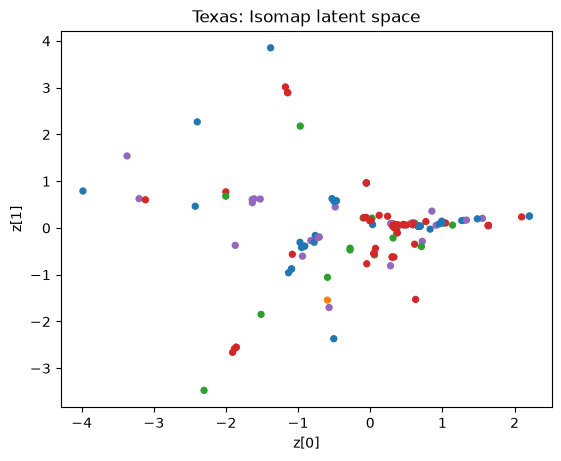

In [28]:
geom_ops = {}
for g in graphs:
    z = isomap_embedding(g.A)
    geom_ops[g.name] = geom_operators(g.A, z)
    A_s = latent_neighbourhood(g.A, z)
    print(f'{g.name:<10} h_edge graph = {edge_homophily(g.A, g.y):.3f} | '
          f'latent-space neighbourhood = {edge_homophily(A_s, g.y):.3f}')

z = isomap_embedding(texas.A).numpy()
fig, ax = plt.subplots(figsize=(5.5, 4.5), constrained_layout=True)
sc = ax.scatter(z[:, 0], z[:, 1], c=texas.y.cpu().numpy(), cmap='tab10', s=18, vmin=0, vmax=9)
ax.set(title='Texas: Isomap latent space', xlabel='z[0]', ylabel='z[1]')
plt.show()

In [29]:
benchmark('Geom-GCN', lambda g, s: GeomGCN(g.F, HIDDEN, g.C, geom_ops[g.name]), graphs, SPLITS)

Geom-GCN   | Texas:  58.6 ±  7.1 | Chameleon:  61.2 ±  2.8 | Cora:  78.5 ±  2.9


# 4. Advanced architectures
Redesign AGGREGATE and UPDATE: let messages repel as well as attract.
## 4.1. Allen-Cahn Message Passing (ACMP)

Nodes are particles with an attractive force (attention $a_{ij}$), a repulsive force ($\beta$) and the Allen-Cahn force from the double-well potential $W(x) = \frac14(1-x^2)^2$:

$$\frac{\partial x_i}{\partial t} = \alpha \odot \Big[\sum_{j} a_{ij}(x_j - x_i) - \beta \sum_j \tfrac{1}{d_i}(x_j - x_i)\Big] + \delta \odot x_i \odot (1 - x_i^2)$$

We solve this neural ODE with Euler steps ($T = 1$, step $0.2$); the attention is computed on the edges at every step.

In [30]:
class ACMP(nn.Module):
    """Allen-Cahn Message Passing (Wang et al., ICLR 2023), Euler solver of
       dx_i/dt = α ⊙ [ Σ_j a_ij (x_j - x_i)  -  β Σ_j (1/d_i) (x_j - x_i) ]  +  δ ⊙ x_i ⊙ (1 - x_i²)
                       attraction (attention)     repulsion (constant β)         Allen-Cahn (double well)
    The attention a_ij = softmax_j(q_i·k_j / sqrt(d)) is computed on the edges (with self-loops) at every step."""
    def __init__(self, in_dim, hidden_dim, out_dim, A, T=1.0, step=0.2, beta=0.5, dropout=0.5):
        super().__init__()
        self.enc, self.dec = nn.Linear(in_dim, hidden_dim), nn.Linear(hidden_dim, out_dim)
        self.q = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.k = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.alpha = nn.Parameter(torch.ones(hidden_dim))       # channel-wise diffusion strength
        self.delta = nn.Parameter(torch.ones(hidden_dim))       # channel-wise Allen-Cahn strength
        I = torch.eye(A.size(0), device=A.device)
        self.rows, self.cols = edges_of(A + I)                  # attention neighbourhood (with self-loops)
        self.P = as_operator(row_norm(A))                       # mean over neighbours (repulsion)
        self.L = as_operator(torch.diag(A.sum(1)) - A)          # combinatorial Laplacian, for the energy
        self.beta, self.steps, self.step, self.dropout = beta, int(round(T / step)), step, dropout
        self.record = False                                     # set True to record the energy at every step

    def energy(self, h):
        """Dirichlet energy  tr(hᵀ L h) / N  (used to show that ACMP does not over-smooth)."""
        return (h * (self.L @ h)).sum().item() / h.size(0)

    def forward(self, x):
        x = input_dropout(x, self.dropout, self.training)
        h = torch.tanh(self.enc(x))                             # start inside the wells (-1, 1)
        N, d = h.shape
        self.energies = [self.energy(h)] if self.record else []
        for _ in range(self.steps):
            scores = (self.q(h)[self.rows] * self.k(h)[self.cols]).sum(1) / math.sqrt(d)
            att = edge_softmax(scores, self.rows, N)
            attraction = edge_matmul(self.rows, self.cols, att, h) - h
            repulsion = self.P @ h - h
            #Balance attraction, repulsion, and the double-well reaction term.
            dh = self.alpha * (attraction - self.beta * repulsion) + self.delta * h * (1 - h ** 2)
            h = h + self.step * dh
            if self.record:
                self.energies.append(self.energy(h))
        self.h = h.detach()
        return self.dec(F.dropout(h, self.dropout, self.training))

In [31]:
benchmark('ACMP', lambda g, s: ACMP(g.F, HIDDEN, g.C, g.A), graphs, SPLITS)

ACMP       | Texas:  82.9 ±  2.5 | Chameleon:  53.1 ±  3.4 | Cora:  81.4 ±  2.1


No over-smoothing. 

Run the dynamics for a long time ($T = 20$, 100 steps) with an untrained model: pure attraction ($\beta = 0, \delta = 0$, i.e. graph diffusion) drives the Dirichlet energy to 0, while ACMP keeps it bounded away from 0.

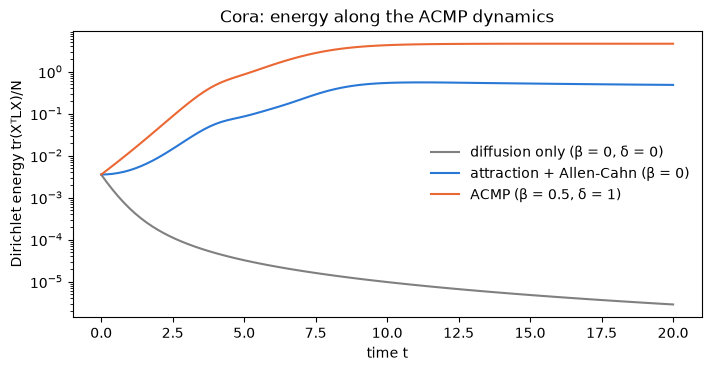

In [32]:
fig, ax = plt.subplots(figsize=(7, 3.6), constrained_layout=True)
for label, beta, delta, c in [('diffusion only (β = 0, δ = 0)', 0., 0., 'gray'),
                              ('attraction + Allen-Cahn (β = 0)', 0., 1., HOMO_COLOR),
                              ('ACMP (β = 0.5, δ = 1)', 0.5, 1., HETERO_COLOR)]:
    set_seed(0)
    model = ACMP(cora.F, HIDDEN, cora.C, cora.A, T=20, step=0.2, beta=beta).to(device).eval()
    with torch.no_grad():
        model.delta.fill_(delta)
        model.record = True
        model(cora.X)
    ax.semilogy(np.arange(len(model.energies)) * 0.2, model.energies, color=c, label=label)
ax.set(xlabel='time t', ylabel='Dirichlet energy tr(XᵀLX)/N', title='Cora: energy along the ACMP dynamics')
ax.legend(frameon=False)
plt.show()

Pure diffusion drives the energy toward 0 (over-smoothing), the Allen-Cahn term alone already prevents the collapse, and the repulsion pushes the energy higher. In both cases the energy saturates: the double-well potential keeps the features near $\pm 1$, so the energy is bounded above and away from 0.

## 4.2. GGCN: signed messages and degree correction

GGCN links over-smoothing and heterophily to the same mechanism and corrects the edges in two ways:

* **structure-based**: rescale each edge with the relative degree $r_{ij} = \frac{d_i+1}{d_j+1}$, $\tau_{ij} = \text{softplus}(\lambda_1 \log r_{ij} + \lambda_2)$;
* **feature-based (signed)**: $s_{ij} = \cos(h_iW, h_jW) \in [-1, 1]$; positive and negative messages get their own learned weights, so a heterophilous neighbour pushes the node away instead of pulling it toward the wrong class.

In [33]:
class GGCNLayer(nn.Module):
    """GGCN layer (Yan et al., ICDM 2022):
    structure-based correction  τ_ij = softplus(λ1 log r_ij + λ2),  r_ij = (d_i + 1) / (d_j + 1)
    feature-based correction    s_ij = cos(h_i W, h_j W) ∈ [-1, 1]   (signed!)
    h_i' = b0 h_i W + b1 Σ_j [τ s]^+_ij h_j W / sqrt(d_i d_j) - b2 Σ_j [τ s]^-_ij h_j W / sqrt(d_i d_j)"""
    def __init__(self, in_dim, out_dim, A):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim)
        self.rows, self.cols = edges_of(A)
        deg = A.sum(1)
        self.log_r = torch.log((deg[self.rows] + 1) / (deg[self.cols] + 1))      # relative degree of every edge
        self.norm = deg[self.rows].pow(-0.5) * deg[self.cols].pow(-0.5)
        self.lam = nn.Parameter(torch.tensor([0.5, 0.]))
        self.b = nn.Parameter(torch.full((3,), math.log(math.e - 1)))   # softplus(b) = 1 at init

    def forward(self, h):
        hw = self.lin(h)
        hn = F.normalize(hw, dim=1)
        s = (hn[self.rows] * hn[self.cols]).sum(1)                      # signed cosine similarity per edge
        tau = F.softplus(self.lam[0] * self.log_r + self.lam[1])
        w = s * tau * self.norm
        self.w = w.detach()
        b = F.softplus(self.b)                                          # weights of ego / positive / negative parts
        pos = edge_matmul(self.rows, self.cols, F.relu(w), hw)
        neg = edge_matmul(self.rows, self.cols, F.relu(-w), hw)
        #Combine ego features with positive messages and subtract negative messages.
        return b[0] * hw + b[1] * pos - b[2] * neg


class GGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, A, dropout=0.5):
        super().__init__()
        self.layer1, self.layer2 = GGCNLayer(in_dim, hidden_dim, A), GGCNLayer(hidden_dim, out_dim, A)
        self.dropout = dropout

    def forward(self, x):
        x = input_dropout(x, self.dropout, self.training)
        x = F.dropout(F.elu(self.layer1(x)), self.dropout, self.training)
        return self.layer2(x)

In [34]:
benchmark('GGCN', lambda g, s: GGCN(g.F, HIDDEN, g.C, g.A), graphs, SPLITS)

GGCN       | Texas:  65.8 ±  4.6 | Chameleon:  53.0 ±  1.9 | Cora:  87.5 ±  1.8


# 5. Graph structure learning
When the given edges are themselves the problem, treat the graph as something to learn or rewrite
## 5.1. Metric-based GSL

$$\mathcal L = \mathcal L_{task}(Z^*, Y) + \lambda\, \mathcal L_{reg}(A^*, Z^*, G)$$

The four steps of the GSL pipeline: 

(1) construction: candidate edges from a kNN graph of the features; 

(2) modelling: a learnable multi-head weighted cosine kernel $S_{ij} = \text{ReLU}\big(\frac1m\sum_h \cos(w_h \odot x_i, w_h \odot x_j)\big)$ on those edges; 

(3) propagation: a GCN on $A^* = m\hat A + (1-m)\,\text{norm}(S)$ with a learned $m$; 

(4) the regularisers smoothness, connectivity and sparsity.

In [35]:
class GSL(nn.Module):
    """Metric-based graph structure learning:
    1. construction : candidate edges = kNN graph of the features X (cosine, k neighbours)
    2. modelling    : learnable multi-head weighted cosine kernel on the candidate edges
                      S_ij = ReLU(mean_h cos(w_h ⊙ x_i, w_h ⊙ x_j))
    3. propagation  : 2-layer GCN on  A* = m · Â + (1 - m) · norm(S),  with m = σ(θ) learned
    4. regularisers : smoothness Σ S_ij ‖x_i - x_j‖², connectivity -1ᵀlog(S1), sparsity ‖S‖²_F  (all / N)."""
    def __init__(self, in_dim, hidden_dim, out_dim, A_hat, X, k=10, heads=2, dropout=0.5,
                 w_smooth=0.1, w_conn=0.01, w_sparse=0.01):
        super().__init__()
        self.rows, self.cols = edges_of(knn_graph(X, k))         # 1. candidate edges
        self.w = nn.Parameter(torch.ones(heads, in_dim))           # 2. metric weights (init = plain cosine)
        self.theta = nn.Parameter(torch.tensor(0.))
        self.lin1, self.lin2 = nn.Linear(in_dim, hidden_dim), nn.Linear(hidden_dim, out_dim)
        self.A_hat, self.dropout = as_operator(A_hat), dropout
        self.dist2 = (X[self.rows] - X[self.cols]).pow(2).sum(1)  # ‖x_i - x_j‖² on the candidate edges
        self.coef = (w_smooth, w_conn, w_sparse)
        # cos(w ⊙ x_i, w ⊙ x_j) = Σ_f w_f² x_if x_jf / (‖w ⊙ x_i‖ ‖w ⊙ x_j‖): precompute the (sparse) products x_if x_jf
        idx, val = [], []
        for s in range(0, len(self.rows), 4096):
            prod = X[self.rows[s:s + 4096]] * X[self.cols[s:s + 4096]]
            nz = prod.nonzero(as_tuple=True)
            idx.append(torch.stack([nz[0] + s, nz[1]]))
            val.append(prod[nz])
        self.P = torch.sparse_coo_tensor(torch.cat(idx, 1), torch.cat(val), (len(self.rows), in_dim)).coalesce()
        self.X2 = X.pow(2)

    def learn_graph(self, x):
        """Learned edge weights S_ij on the candidate edges (symmetric, since the kNN graph is symmetric)."""
        W2 = self.w.pow(2).t()                                           # (in_dim, heads)
        num = torch.sparse.mm(self.P, W2)                                # (E, heads)
        norms = (self.X2 @ W2).clamp(min=1e-12).sqrt()                   # (N, heads)
        cos = num / (norms[self.rows] * norms[self.cols])
        #Learn edge strengths using a trainable weighted cosine metric.
        return F.relu(cos.mean(1))

    def forward(self, x):
        N = x.size(0)
        self.S = self.learn_graph(x)
        deg = torch.zeros(N, device=x.device).index_add_(0, self.rows, self.S) + 1      # + self-loop
        norm = deg[self.rows].pow(-0.5) * self.S * deg[self.cols].pow(-0.5)
        m = torch.sigmoid(self.theta)
        def propagate(h):                                                               # A* h
            learned = edge_matmul(self.rows, self.cols, norm, h) + h / deg[:, None]
            #Learn how much to trust the original graph versus the learned graph.
            return m * (self.A_hat @ h) + (1 - m) * learned
        h = input_dropout(x, self.dropout, self.training)
        h = F.dropout(F.relu(propagate(self.lin1(h))), self.dropout, self.training)
        return propagate(self.lin2(h))

    def reg_loss(self):
        S, N = self.S, self.A_hat.size(0)
        deg = torch.zeros(N, device=S.device).index_add_(0, self.rows, S)
        smooth = (S * self.dist2).sum() / N
        conn = -torch.log(deg + 1e-6).mean() / N
        sparse = S.pow(2).sum() / N
        a, b, c = self.coef
        return a * smooth + b * conn + c * sparse

In [36]:
benchmark('GSL', lambda g, s: GSL(g.F, HIDDEN, g.C, g.A_hat, g.X), graphs, SPLITS)

GSL        | Texas:  73.9 ±  2.5 | Chameleon:  48.1 ±  2.3 | Cora:  87.1 ±  1.2


## 5.2. MVGFN: multi-view graph fusion 

Build three extra views with higher homophily: the 2-hop graph $\mathcal N_2$, a kNN graph on the semantic features $\mathcal N_{se}$, a kNN graph on structural features $\mathcal N_{st}$ (here the rows of $A$). A shared GAT runs on every view and the views are fused with learned softmax weights $\hat w_p$.

In [37]:
class GAT(nn.Module):
    """Single-head GAT layer  h_i' = Σ_j softmax_j(LeakyReLU(a_iᵀ W h_i + a_jᵀ W h_j)) W h_j.
    A sparse graph is processed on its edge list, a dense one (e.g. a 2-hop graph) with a masked N × N matrix."""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=False)
        self.a_i, self.a_j = nn.Linear(out_dim, 1, bias=False), nn.Linear(out_dim, 1, bias=False)

    @staticmethod
    def prepare(A):
        """Graph structure used by forward(): edge list if sparse, boolean mask if dense (self-loops added)."""
        A = A + torch.eye(A.size(0), device=A.device)
        return edges_of(A) if (A > 0).float().mean() < 0.05 else A > 0

    def forward(self, x, graph, h=None):
        h = self.lin(x) if h is None else h                        # pass h to reuse the projection
        s_i, s_j = self.a_i(h), self.a_j(h)
        if isinstance(graph, tuple):                               # edge list
            rows, cols = graph
            att = edge_softmax(F.leaky_relu(s_i[rows, 0] + s_j[cols, 0], 0.2), rows, h.size(0))
            return edge_matmul(rows, cols, att, h)
        e = F.leaky_relu(s_i + s_j.t(), 0.2)                       # dense masked attention
        return torch.softmax(e.masked_fill(~graph, float('-inf')), dim=1) @ h


class MVGFN(nn.Module):
    """Multi-View Graph Fusion Network (ICME 2023): four views, a shared GAT, softmax-weighted fusion.
    N1 = original graph, N2 = 2-hop graph, Nse = kNN on semantic features X, Nst = kNN on structural features (rows of A)."""
    def __init__(self, in_dim, hidden_dim, out_dim, A, X, k=5, dropout=0.5):
        super().__init__()
        I = torch.eye(A.size(0), device=A.device)
        #Build four views: original, 2-hop, feature similarity, and structural similarity.
        self.views = {'N1': A, 'N2': two_hop(A), 'Nse': knn_graph(X, k), 'Nst': knn_graph(A + I, k)}
        self.graphs = [GAT.prepare(V) for V in self.views.values()]
        self.gat = GAT(in_dim, hidden_dim)                       # shared across views
        self.w = nn.Parameter(torch.zeros(len(self.graphs)))     # view weights
        self.cls = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

    def view_weights(self):
        return dict(zip(self.views, torch.softmax(self.w, 0).tolist()))

    def forward(self, x):
        x = input_dropout(x, self.dropout, self.training)
        w = torch.softmax(self.w, 0)
        xw = self.gat.lin(x)
        #Fuse the views with learned weights and a shared attention layer.
        h = sum(w[p] * F.elu(self.gat(x, graph, xw)) for p, graph in enumerate(self.graphs))
        return self.cls(F.dropout(h, self.dropout, self.training))

In [38]:
view_h = {}
for g in graphs:
    views = MVGFN(g.F, HIDDEN, g.C, g.A, g.X).views
    view_h[g.name] = {p: edge_homophily(V, g.y) for p, V in views.items()}
pd.DataFrame(view_h).T.round(3).rename(columns=lambda p: f'h_edge({p})')

,h_edge(N1),h_edge(N2),h_edge(Nse),h_edge(Nst)
Texas,0.061,0.571,0.644,0.560
Chameleon,0.230,0.228,0.251,0.665
Cora,0.810,0.724,0.566,0.739


In [39]:
benchmark('MVGFN', lambda g, s: MVGFN(g.F, HIDDEN, g.C, g.A, g.X), graphs, SPLITS)

MVGFN      | Texas:  75.7 ±  0.0 | Chameleon:  68.6 ±  2.9 | Cora:  87.0 ±  1.8


In [40]:
weights = {}
for g in graphs:
    set_seed(0)
    model = MVGFN(g.F, HIDDEN, g.C, g.A, g.X)
    train_model(model, g, 0)
    weights[g.name] = model.view_weights()
pd.DataFrame(weights).T.round(3).rename(columns=lambda p: f'ŵ({p})')

,ŵ(N1),ŵ(N2),ŵ(Nse),ŵ(Nst)
Texas,0.018,0.029,0.937,0.015
Chameleon,0.030,0.029,0.046,0.895
Cora,0.517,0.238,0.114,0.131


MVGFN picks one dominant view per dataset, and it is the one that suits the dataset: the semantic kNN graph $\mathcal N_{se}$ on Texas (the features are very informative), the structural kNN graph $\mathcal N_{st}$ on Chameleon (the most homophilous view, 0.67), and the original graph on Cora. 

This makes MVGFN the best model on Chameleon.

## 5.3. DHGR: rewiring with neighbourhood distributions

Raw features are poor predictors of whether an edge is homophilous. 

DHGR compares neighbourhoods instead: the neighbour feature distribution $\text{NFD} = D^{-1}AX$ and the neighbour label distribution $\text{NLD} = D^{-1}AY_{train}$, $S_{ij} = \alpha\,\text{sim}(\text{NFD}_i, \text{NFD}_j) + \beta\,\text{sim}(\text{NLD}_i, \text{NLD}_j)$. 

Then it adds the most similar pairs and prunes the least similar edges, and feeds the new graph to any GNN (GCN).

In [41]:
def dhgr_rewire(g, split, k_add=3, prune_ratio=0.5, alpha=1.0, beta=1.0, use_nfd=True, use_nld=True, y_known=None):
    """DHGR-style rewiring (Bi et al., TKDE 2024), training-free version.
    NFD = D^-1 A X (neighbour feature distribution), NLD = D^-1 A Y_train (neighbour label distribution)
    S_ij = α cos(NFD_i, NFD_j) + β cos(NLD_i, NLD_j);  add the k_add most similar non-edges of every node,
    remove the prune_ratio fraction of existing edges with the lowest similarity.
    y_known: which labels may be used (default: training labels only)."""
    A, N = g.A, g.N
    train = g.split(split)[0] if y_known is None else y_known
    deg = A.sum(1, keepdim=True).clamp(min=1)
    S, W = torch.zeros(N, N, device=A.device), torch.zeros(N, N, device=A.device)
    if use_nfd:
        #Compare neighbourhood feature distributions rather than raw node features.
        S, W = S + alpha * cosine_sim(A @ g.X / deg), W + alpha
    if use_nld:
        #Mask labels to training nodes before computing neighbourhood label similarity.
        Y = F.one_hot(g.y, g.C).float() * train[:, None]
        counts = A @ Y
        valid = (counts.sum(1) > 0).float()                         # nodes with ≥ 1 labelled neighbour
        V = valid[:, None] * valid[None, :]
        S, W = S + beta * V * cosine_sim(counts), W + beta * V
    S = S / W.clamp(min=1e-12)
    S.fill_diagonal_(-float('inf'))
    # 1) prune: drop the least similar existing edges
    A_new = A.clone()
    if prune_ratio > 0:
        src, dst = edges_of(torch.triu(A, 1))
        n_drop = int(prune_ratio * len(src))
        drop = S[src, dst].argsort()[:n_drop]
        A_new[src[drop], dst[drop]] = 0
        A_new[dst[drop], src[drop]] = 0
    # 2) add: connect every node to its k_add most similar nodes
    if k_add > 0:
        idx = S.topk(k_add, dim=1).indices
        A_add = torch.zeros_like(A).scatter_(1, idx, 1.)
        A_new = ((A_new + A_add + A_add.t()) > 0).float()
    A_new.fill_diagonal_(0)
    return A_new

In [42]:
for g in graphs:
    A_new = dhgr_rewire(g, 0)
    print(f'{g.name:<10} edges {int(g.A.sum()) // 2:>6} -> {int(A_new.sum()) // 2:>6} | '
          f'h_edge {edge_homophily(g.A, g.y):.3f} -> {edge_homophily(A_new, g.y):.3f} | '
          f'h_adj {adjusted_homophily(g.A, g.y):+.3f} -> {adjusted_homophily(A_new, g.y):+.3f}')

Texas      edges    279 ->    566 | h_edge 0.061 -> 0.498 | h_adj -0.294 -> +0.219
Chameleon  edges  31371 ->  20140 | h_edge 0.230 -> 0.372 | h_adj +0.032 -> +0.198
Cora       edges   5278 ->   7809 | h_edge 0.810 -> 0.817 | h_adj +0.771 -> +0.778


In [43]:
benchmark('DHGR', lambda g, s: GCN(g.F, HIDDEN, g.C, sym_norm(dhgr_rewire(g, s))), graphs, SPLITS)

DHGR       | Texas:  65.8 ±  2.5 | Chameleon:  64.3 ±  1.9 | Cora:  85.2 ±  2.0


The rewired graphs are much more homophilous on Texas and Chameleon, and the same GCN gains about 12 points on Texas and 10 points on Chameleon. 

On Cora the rewiring changes little (the graph is already homophilous) and costs a bit of accuracy.

## 5.4. ConSM: confidence-based subgraph matching

Removing edges is dangerous (removing assortative edges hurts much more than removing disassortative ones), so ConSM weights them. 

Instead of comparing two nodes, it compares their sub-graphs with optimal transport, prunes a confidence ratio of the least similar edges, and weights the rest by their similarity. 

We use entropic OT (Sinkhorn) between $\{i\}\cup N(i)$ and $\{j\}\cup N(j)$ in the hidden space of an MLP trained on the training labels, and then train a GCN on the weighted graph.

In [44]:
def fit_mlp(g, split, hidden_dim=64, epochs=200):
    """Train an MLP on the training nodes of `split`; return (softmax probabilities, hidden representations)."""
    set_seed(split)
    mlp = MLP(g.F, hidden_dim, g.C)
    train_model(mlp, g, split, epochs=epochs, patience=50)
    mlp.eval()
    with torch.no_grad():
        prob = torch.softmax(mlp(g.X), 1)
    return prob, mlp.hidden.detach()

def sinkhorn(C, a, b, eps=0.1, iters=50):
    """Batched entropic optimal transport in the log domain. C: (B, m, m) costs, a, b: (B, m) masses (0 = padding).
    Returns the transport cost <P, C> of every pair."""
    log_a, log_b = a.clamp(min=1e-30).log(), b.clamp(min=1e-30).log()
    f, g_ = torch.zeros_like(a), torch.zeros_like(b)
    for _ in range(iters):
        f = eps * (log_a - torch.logsumexp((g_[:, None, :] - C) / eps, dim=2))
        g_ = eps * (log_b - torch.logsumexp((f[:, :, None] - C) / eps, dim=1))
    P = torch.exp((f[:, :, None] + g_[:, None, :] - C) / eps)
    return (P * C).sum((1, 2))

def consm_reweight(g, split, conf_ratio=0.3, m=8, batch=4096):
    """ConSM-style edge re-weighting (Sun et al., CIKM 2022):
    1. node representations H = hidden layer of an MLP trained on the training labels,
    2. for each edge (i, j): optimal-transport distance between the sub-graphs {i} ∪ N(i) and {j} ∪ N(j),
    3. drop the conf_ratio fraction of least-confident edges, weight the others by their similarity 1 - OT/2."""
    _, H = fit_mlp(g, split)
    H = F.normalize(H, dim=1)
    N, A = g.N, g.A
    gen = torch.Generator().manual_seed(split)
    nbr = torch.zeros(N, m, dtype=torch.long)                   # sub-graph = node + up to m-1 sampled neighbours
    msk = torch.zeros(N, m)
    for v in range(N):
        nb = A[v].nonzero().flatten().cpu()
        nb = nb[torch.randperm(len(nb), generator=gen)[:m - 1]]
        nodes = torch.cat([torch.tensor([v]), nb])
        nbr[v, :len(nodes)], msk[v, :len(nodes)] = nodes, 1
    nbr, msk = nbr.to(device), msk.to(device)
    src, dst = edges_of(torch.triu(A, 1))
    ot = []
    for s in range(0, len(src), batch):
        i, j = src[s:s + batch], dst[s:s + batch]
        C = 1 - H[nbr[i]] @ H[nbr[j]].transpose(1, 2)            # cosine cost between the two sub-graphs
        a = msk[i] / msk[i].sum(1, keepdim=True)
        b = msk[j] / msk[j].sum(1, keepdim=True)
        #Compare whole sampled neighbourhoods through optimal transport.
        ot.append(sinkhorn(C, a, b))
    ot = torch.cat(ot)
    sim = (1 - ot / 2).clamp(min=0)
    #Prune low-confidence edges, then weight retained edges by similarity.
    keep = sim.argsort(descending=True)[:int((1 - conf_ratio) * len(sim))]
    W = torch.zeros_like(A)
    W[src[keep], dst[keep]] = sim[keep]
    W[dst[keep], src[keep]] = sim[keep]
    return W

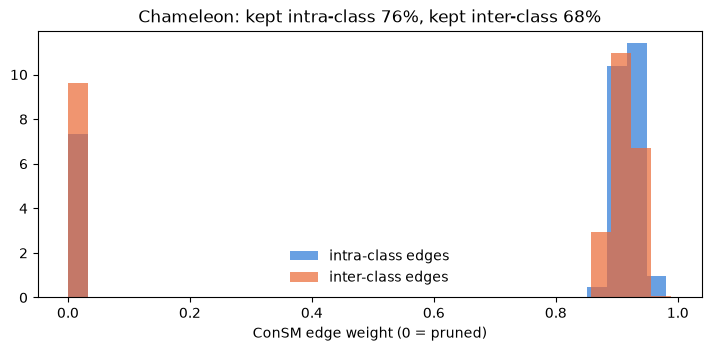

In [45]:
W = consm_reweight(chameleon, 0)
src, dst = edges_of(chameleon.A)
same = (chameleon.y[src] == chameleon.y[dst]).cpu().numpy()
w = W[src, dst].cpu().numpy()
fig, ax = plt.subplots(figsize=(7, 3.4), constrained_layout=True)
ax.hist(w[same], bins=30, alpha=0.7, density=True, color=HOMO_COLOR, label='intra-class edges')
ax.hist(w[~same], bins=30, alpha=0.7, density=True, color=HETERO_COLOR, label='inter-class edges')
ax.set(xlabel='ConSM edge weight (0 = pruned)', title=f'Chameleon: kept intra-class {np.mean(w[same] > 0):.0%}, '
       f'kept inter-class {np.mean(w[~same] > 0):.0%}')
ax.legend(frameon=False)
plt.show()

In [46]:
benchmark('ConSM', lambda g, s: GCN(g.F, HIDDEN, g.C, sym_norm(consm_reweight(g, s))), graphs, SPLITS)

ConSM      | Texas:  53.2 ±  3.4 | Chameleon:  55.8 ±  2.3 | Cora:  86.9 ±  2.1


ConSM keeps more intra-class than inter-class edges, but re-weighting/pruning only 30 % of the edges is not enough to turn Texas or Chameleon into homophilous graphs: the GCN on top stays close to the plain GCN. 

ConSM is designed to refine a graph (its strength is on graphs with a moderate amount of noise), not to rebuild it.

## 5.5. LGR: label-guided graph rewiring

Raw cosine similarity does not separate intra- from inter-class pairs on heterophilous graphs, so LGR guides the rewiring with labels:

1. class probabilities $\hat Y$ from an MLP (training rows replaced by the one-hot ground truth),
2. class embeddings $L_c$ from a shared auto-encoder; each node gets the weighted class embedding $E_i = \sum_c \hat Y_{ic} L_c$ and the features are augmented to $\tilde X_i = X_i \,\|\, E_i$,
3. two-stage rewiring with $S_{ij} = \cos(E_i, E_j)$: insert the most similar nodes from the multi-hop neighbourhood, delete dissimilar neighbours.

In [47]:
def lgr_rewire(g, split, latent_dim=32, k_add=3, hops=3, delete_below=0.5, ae_epochs=200):
    """LGR-style label-guided rewiring (TNNLS 2025).
    Stage 1: MLP class probabilities Ŷ (training rows replaced by one-hot ground truth),
    Stage 2: shared auto-encoder -> class embeddings L_c (mean latent code of class c),
             weighted class embedding E_i = Σ_c Ŷ_ic L_c, used to augment the features: X̃ = [X ‖ E],
    Stage 3: S_ij = cos(E_i, E_j): insert the k_add most similar nodes within `hops` hops, delete edges with S < delete_below.
    Returns (rewired adjacency A_R, extra features E)."""
    prob, _ = fit_mlp(g, split)
    train = g.split(split)[0]
    #Use ground-truth labels only for training nodes; other nodes keep predictions.
    prob[train] = F.one_hot(g.y[train], g.C).float()
    # Stage 2: auto-encoder shared by all classes
    set_seed(split)
    enc = nn.Sequential(nn.Linear(g.F, 128), nn.ReLU(), nn.Linear(128, latent_dim)).to(device)
    dec = nn.Sequential(nn.Linear(latent_dim, 128), nn.ReLU(), nn.Linear(128, g.F)).to(device)
    opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=0.01)
    for _ in range(ae_epochs):
        opt.zero_grad()
        loss = F.mse_loss(dec(enc(g.X)), g.X)
        loss.backward()
        opt.step()
    with torch.no_grad():
        Z = enc(g.X)
        L = (prob.t() @ Z) / prob.sum(0)[:, None].clamp(min=1e-12)   # (C, latent) class embeddings
        #Represent each node as a probability-weighted mixture of class embeddings.
        E = prob @ L                                                   # (N, latent) weighted class embedding
    # Stage 3: class-embedding-guided rewiring
    #Guide edge insertion and deletion with class-embedding similarity.
    S = cosine_sim(E)
    I = torch.eye(g.N, device=device)
    reach = torch.linalg.matrix_power(g.A + I, hops) > 0
    cand = S.masked_fill(~reach | (g.A > 0) | (I > 0), -float('inf'))
    vals, idx = cand.topk(k_add, dim=1)
    A_add = torch.zeros_like(g.A).scatter_(1, idx, (vals > -float('inf')).float())     # insertion
    A_R = g.A * (S >= delete_below).float()                          # deletion of dissimilar neighbours
    A_R = ((A_R + A_add + A_add.t()) > 0).float()
    A_R.fill_diagonal_(0)
    return A_R, F.normalize(E, dim=1)


class WithExtraFeatures(nn.Module):
    """Wrap a model so that it receives [X ‖ extra] as input."""
    def __init__(self, model, extra):
        super().__init__()
        self.model, self.extra = model, extra

    def forward(self, x):
        return self.model(torch.cat([x, self.extra], dim=1))

In [48]:
for g in graphs:
    A_R, _ = lgr_rewire(g, 0)
    print(f'{g.name:<10} edges {int(g.A.sum()) // 2:>6} -> {int(A_R.sum()) // 2:>6} | '
          f'h_edge {edge_homophily(g.A, g.y):.3f} -> {edge_homophily(A_R, g.y):.3f}')

Texas      edges    279 ->    766 | h_edge 0.061 -> 0.520
Chameleon  edges  31371 ->  37396 | h_edge 0.230 -> 0.300
Cora       edges   5278 ->  11684 | h_edge 0.810 -> 0.844


In [49]:
def make_lgr(g, s):
    A_R, E = lgr_rewire(g, s)
    return WithExtraFeatures(GCN(g.F + E.size(1), HIDDEN, g.C, sym_norm(A_R)), E)

benchmark('LGR', make_lgr, graphs, SPLITS)

LGR        | Texas:  65.8 ±  6.7 | Chameleon:  50.4 ±  1.7 | Cora:  86.5 ±  1.8


LGR raises the homophily of Texas from 0.06 to 0.5 and improves the GCN by about 10 points there. 

On Chameleon the MLP pseudo-labels are poor (the MLP only reaches 47 %), so the label-guided edges are noisy as well: a label-guided method is only as good as the labels that guide it.

# 6. Graph transformers: SignGT

Softmax attention weights are all positive, so global attention is a smoothing (low-pass) operator. Signed self-attention keeps the sign of the query–key score and normalises the magnitudes:

$$M_{ij} = \frac{\text{sgn}(q_i k_j^\top)\,\exp(|q_i k_j^\top|)}{\sum_k \exp(|q_i k_k^\top|)}$$

and the structure-aware FFN $H'' = \text{Linear}(\sigma(\bar A\, \text{Linear}(H')))$, $\bar A = \hat A^k$, re-injects the local topology.

In [50]:
class SignSA(nn.Module):
    """Signed self-attention (SignGT):  M_ij = sgn(q_i·k_j) exp(|q_i·k_j|) / Σ_k exp(|q_i·k_k|).
    signed=False gives the standard softmax attention (all weights > 0 -> pure smoothing)."""
    def __init__(self, dim, heads=2, signed=True):
        super().__init__()
        self.qkv, self.out = nn.Linear(dim, 3 * dim), nn.Linear(dim, dim)
        self.heads, self.signed = heads, signed

    def forward(self, h):
        N, d = h.shape
        q, k, v = self.qkv(h).view(N, 3, self.heads, d // self.heads).permute(1, 2, 0, 3)
        s = q @ k.transpose(1, 2) / math.sqrt(d // self.heads)       # (heads, N, N)
        #Signed attention preserves negative interactions while normalising magnitudes.
        M = torch.sign(s) * torch.softmax(s.abs(), dim=-1) if self.signed else torch.softmax(s, dim=-1)
        self.M = M.detach()
        return self.out((M @ v).transpose(0, 1).reshape(N, d))


class SFFN(nn.Module):
    """Structure-aware FFN:  Linear(σ(Ā Linear(H))),  Ā = Â^k (non-parametric k-hop structural bias)."""
    def __init__(self, dim, A_bar):
        super().__init__()
        self.lin1, self.lin2, self.A_bar = nn.Linear(dim, dim), nn.Linear(dim, dim), A_bar

    def forward(self, h):
        h = self.lin1(h)
        if self.A_bar is not None:
            #Reintroduce graph structure inside the feed-forward block.
            h = self.A_bar @ h
        return self.lin2(F.gelu(h))


class SignGT(nn.Module):
    """SignGT: [h + SignSA(LN h)] then [h + SFFN(LN h)], stacked; sffn=False uses a standard FFN."""
    def __init__(self, in_dim, hidden_dim, out_dim, A_hat, num_layers=1, heads=2, k=2,
                 signed=True, sffn=True, dropout=0.5):
        super().__init__()
        A_bar = as_operator(torch.linalg.matrix_power(A_hat, k)) if sffn else None
        self.inp, self.out = nn.Linear(in_dim, hidden_dim), nn.Linear(hidden_dim, out_dim)
        self.attn = nn.ModuleList([SignSA(hidden_dim, heads, signed) for _ in range(num_layers)])
        self.ffn = nn.ModuleList([SFFN(hidden_dim, A_bar) for _ in range(num_layers)])
        self.ln1 = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(num_layers)])
        self.ln2 = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(num_layers)])
        self.final_ln, self.dropout = nn.LayerNorm(hidden_dim), dropout

    def forward(self, x):
        h = self.inp(input_dropout(x, self.dropout, self.training))
        for attn, ffn, ln1, ln2 in zip(self.attn, self.ffn, self.ln1, self.ln2):
            h = h + F.dropout(attn(ln1(h)), self.dropout, self.training)
            h = h + F.dropout(ffn(ln2(h)), self.dropout, self.training)
        return self.out(F.dropout(self.final_ln(h), self.dropout, self.training))

SignGT is trained with lr 0.005 and without weight decay: with weight decay 5e-4 the input projection of the transformer cannot grow enough for the tiny row-normalised Cora features and the model stays at the majority class.

In [51]:
benchmark('SignGT', lambda g, s: SignGT(g.F, HIDDEN, g.C, g.A_hat), graphs, SPLITS, lr=0.005, weight_decay=0)

SignGT     | Texas:  67.6 ±  3.8 | Chameleon:  58.3 ±  2.9 | Cora:  86.0 ±  1.9


In [52]:
sign_rows = {}
for g in graphs:
    set_seed(0)
    model = SignGT(g.F, HIDDEN, g.C, g.A_hat)
    train_model(model, g, 0, lr=0.005, weight_decay=0)
    model.eval()
    with torch.no_grad():
        model(g.X)
    M = model.attn[-1].M.mean(0)                                 # signed attention, averaged over heads
    same = (g.y[:, None] == g.y[None, :]).float()
    sign_rows[g.name] = {'share of negative weights': (M < 0).float().mean().item(),
                         'net weight on same-class nodes': (M * same).sum(1).mean().item(),
                         'net weight on other-class nodes': (M * (1 - same)).sum(1).mean().item()}
pd.DataFrame(sign_rows).T.round(3)

,share of negative weights,net weight on same-class nodes,net weight on other-class nodes
Texas,0.000,0.373,0.627
Chameleon,0.597,-0.018,-0.096
Cora,0.675,0.003,-0.208


* SignGT uses many negative weights (two thirds of all weights on Texas and Chameleon).
* On the heterophilous graphs the net weight on other-class nodes is negative (about $-0.38$): the attention subtracts the representations of the other classes, a high-pass operation that softmax attention cannot express. On Texas the net weight on same-class nodes stays positive.
* On Cora most weights are positive and both net weights are positive: the model behaves like a smoothing (low-pass) operator, which is what a homophilous graph needs.

# 7. Summary

In [53]:
table = results_table()
table

,Texas,Chameleon,Cora
MLP,78.4 ± 3.8,46.4 ± 1.3,75.5 ± 3.2
GCN,59.5 ± 4.4,55.8 ± 3.1,87.8 ± 1.6
GPR-GNN,67.6 ± 5.8,57.5 ± 2.4,88.5 ± 1.3
ACM-GCN,78.4 ± 5.8,47.9 ± 0.5,87.3 ± 0.9
ACMII-GCN,72.1 ± 16.6,50.9 ± 2.0,79.4 ± 5.9
FAGCN,66.7 ± 7.1,61.0 ± 2.5,88.9 ± 1.7
H2GCN,81.1 ± 5.8,55.9 ± 2.0,88.9 ± 1.7
Geom-GCN,58.6 ± 7.1,61.2 ± 2.8,78.5 ± 2.9
ACMP,82.9 ± 2.5,53.1 ± 3.4,81.4 ± 2.1
GGCN,65.8 ± 4.6,53.0 ± 1.9,87.5 ± 1.8


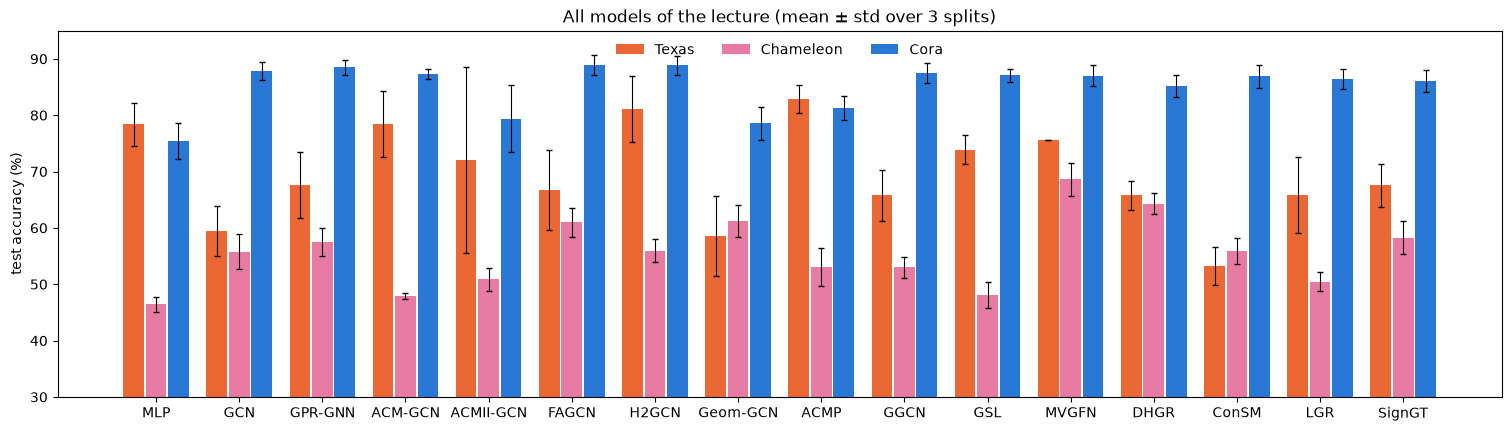

In [54]:
order = list(table.index)
fig, ax = plt.subplots(figsize=(15, 4.2), constrained_layout=True)
width = 0.27
for i, (g, c) in enumerate(zip(graphs, [HETERO_COLOR, "#e87ba4", HOMO_COLOR])):
    means = [RESULTS[(m, g.name)].mean() * 100 for m in order]
    stds = [RESULTS[(m, g.name)].std() * 100 for m in order]
    ax.bar(np.arange(len(order)) + (i - 1) * width, means, width * 0.92, yerr=stds, color=c, label=g.name,
           error_kw=dict(lw=0.8, capsize=2))
ax.set(xticks=range(len(order)), xticklabels=order, ylabel='test accuracy (%)', ylim=(30, 95),
       title=f'All models of the lecture (mean ± std over {len(SPLITS)} splits)')
ax.legend(ncol=3, frameon=False, loc='upper center')
ax.grid(axis='x', visible=False)
plt.show()

* **Texas** (malignant heterophily): the winners are the models that protect the ego features: H2GCN, ACMP, ACM-GCN, GSL (with its feature kNN graph), all at the level of the MLP (≈ 80 %), 20+ points above GCN.
* **Chameleon** (benign heterophily): the neighbourhood is informative but noisy, and the best models change which neighbours are used: MVGFN (structural kNN view), DHGR (rewiring), Geom-GCN (latent-space neighbours), FAGCN and GPR-GNN; the MLP is 20 points behind.
* **Cora** (homophily): almost every graph model is at 84–89 %; the models that rely mostly on the ego features (ACMII, ACMP, Geom-GCN with its many relation channels) lose a few points.
* No single remedy wins everywhere: the right one depends on which kind of heterophily the graph has, which is why the diagnosis matters.

### Takeaways
* **Diagnose first.** Edge homophily alone cannot tell good from bad heterophily; label informativeness, the compatibility matrix and CPM give a fuller picture, and the label spectrum shows why a low-pass GCN fails.
* **Beyond low-pass.** Learnable (GPR-GNN), multi-channel (ACM) and signed (FAGCN, GGCN) filters can keep the high-frequency label signal, and the identity / ego channel lets a node ignore an uninformative neighbourhood.
* **Beyond local.** 2-hop neighbourhoods are often more homophilous than 1-hop ones on heterophilous graphs (H2GCN, MVGFN); latent-space neighbours (Geom-GCN) reach same-class nodes that are far away in the graph.
* **Beyond the given $A$.** Structure learning and rewiring (GSL, MVGFN, DHGR, ConSM, LGR) build a graph that is more homophilous for the task; label-guided methods must only use training labels.
* **Global attention** must be able to produce negative weights (SignGT) to act as anything other than a smoothing filter.
* On small heterophilous graphs such as Texas, a strong MLP is a hard baseline: most of the gain of the heterophily-aware models comes from not destroying the ego features. With test sets of 37 nodes (one node = 2.7 points), differences of a few points are within the noise.